# Pix2Pix — krawędzie (Canny) → kolorowe twarze

Pix2Pix (Isola et al., 2017) tłumaczy obraz na obraz. Generator dostaje **konkretny obraz X** i musi wygenerować odpowiadający mu **obraz Y**.

**mapa krawędzi Canny → fotorealistyczna twarz w kolorze**
Pary `(X, Y)` tworzone automatycznie z CelebA — żadnych dodatkowych labelek.


In [12]:
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

In [13]:
torch.manual_seed(42)

# Włącz auto-tuning kerneli cuDNN dla stałego rozmiaru wejścia
torch.backends.cudnn.benchmark = True

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE    = 64
BATCH_SIZE  = 64
LR          = 2e-4
LAMBDA_L1   = 100
MAX_EPOCHS  = 30
DATA_ROOT   = "../data/"
NUM_WORKERS = min(8, os.cpu_count())

print(f"Urządzenie: {DEVICE} | Workers: {NUM_WORKERS}")

Urządzenie: cuda | Workers: 8


## Dataset: CelebA — pary (krawędzie Canny, kolor)

Wejście X to mapa krawędzi — wygląda jak szkic twarzy.  
Generator musi z tego szkicu odtworzyć fotorealistyczną twarz w kolorze.

In [14]:
def canny_tensor(pil_img, low=80, high=160):
    arr  = np.array(pil_img)
    gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, low, high).astype(np.float32) / 255.0
    # 3 kanały (żeby pasowało do architektury), zakres [-1, 1]
    t = torch.from_numpy(edges).unsqueeze(0).repeat(3, 1, 1)
    return t * 2.0 - 1.0


class CelebAEdges(Dataset):
    def __init__(self, root, split="train"):
        self.base = datasets.CelebA(
            root=root, split=split,
            target_type="attr",
            transform=None,
            download=True,
        )
        self.crop_resize = transforms.Compose([
            transforms.CenterCrop(178),
            transforms.Resize(IMG_SIZE),
        ])
        self.to_tensor = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        pil_img, _ = self.base[idx]
        pil_img    = self.crop_resize(pil_img)
        color      = self.to_tensor(pil_img)
        edges      = canny_tensor(pil_img)
        return edges, color


dataset     = CelebAEdges(DATA_ROOT)
data_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,   # równoległe ładowanie danych
    pin_memory=True,           # szybki transfer CPU→GPU
    persistent_workers=True,   # nie restartuj workerów między epokami
    prefetch_factor=2,
)
print(f"Rozmiar datasetu: {len(dataset):,}")

Rozmiar datasetu: 162,770


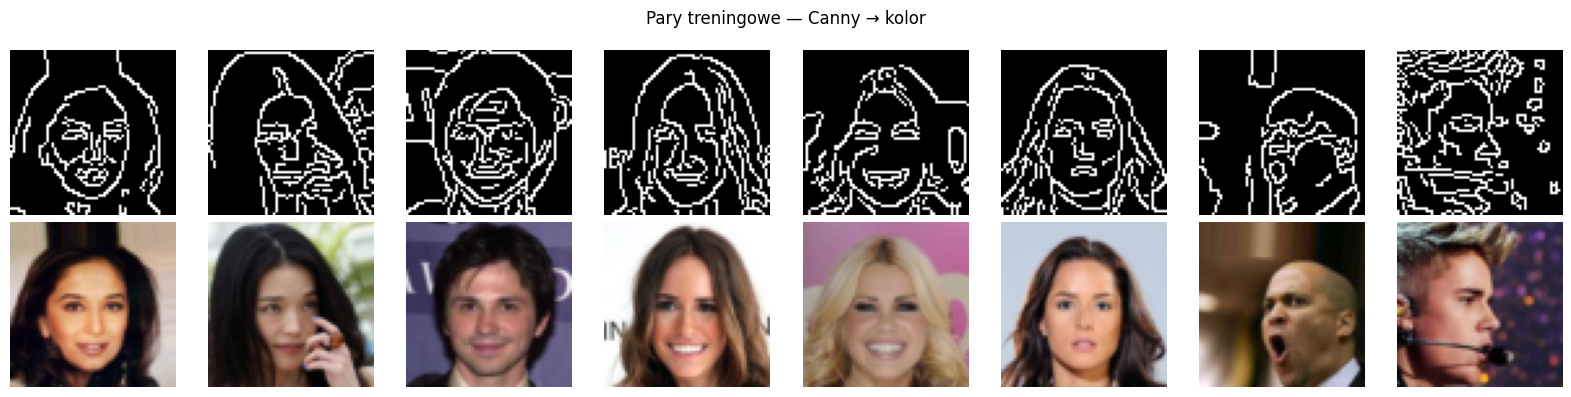

In [15]:
edge_batch, color_batch = next(iter(data_loader))

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for col in range(8):
    axes[0][col].imshow(edge_batch[col][0].numpy() * 0.5 + 0.5, cmap="gray")
    axes[0][col].axis("off")
    axes[1][col].imshow((color_batch[col].permute(1,2,0).numpy() * 0.5 + 0.5).clip(0,1))
    axes[1][col].axis("off")

axes[0][0].set_ylabel("Wejście (X)\nkrawędzie", fontsize=9)
axes[1][0].set_ylabel("Cel (Y)\nkolor", fontsize=9)
plt.suptitle("Pary treningowe — Canny → kolor")
plt.tight_layout(); plt.show()

## Architektura

### Generator — U-Net
Skip connections przepisują strukturę z enkodera do dekodera.  
Dekoder nie musi rekonstruować kształtów od zera — dostaje je gotowe.

```
Enkoder:  64→32→16→8→4  (downsampling)
Dekoder:   4→8→16→32→64 (upsampling)
              ↑   ↑   ↑   ↑  (skip connections)
```

### Dyskryminator — PatchGAN
Wyjście to mapa `~6×6` — każda wartość to ocena lokalnego patcha.  
Wymusza lokalną spójność tekstury, nie tylko globalną strukturę.

### Loss
```
L_D = BCE(D(x, y_real), 1) + BCE(D(x, y_fake), 0)
L_G = BCE(D(x, y_fake), 1) + 100 * L1(y_fake, y_real)
```
L1 z wagą 100 wymusza wierność kolorów — bez niego generator może "halucynować" dowolne kolory.

In [16]:
def enc_block(in_ch, out_ch, normalize=True):
    layers = [nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=False)]
    if normalize:
        layers.append(nn.BatchNorm2d(out_ch))
    layers.append(nn.LeakyReLU(0.2, inplace=True))
    return nn.Sequential(*layers)

def dec_block(in_ch, out_ch, dropout=False):
    layers = [
        nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=False),
        nn.BatchNorm2d(out_ch),
    ]
    if dropout:
        layers.append(nn.Dropout(0.5))
    layers.append(nn.ReLU(inplace=True))
    return nn.Sequential(*layers)


class UNetGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.e1 = enc_block(3,   64,  normalize=False)
        self.e2 = enc_block(64,  128)
        self.e3 = enc_block(128, 256)
        self.e4 = enc_block(256, 512)

        self.d1 = dec_block(512,      256, dropout=True)
        self.d2 = dec_block(256+256,  128)
        self.d3 = dec_block(128+128,  64)
        self.d4 = nn.Sequential(
            nn.ConvTranspose2d(64+64, 3, 4, 2, 1),
            nn.Tanh(),
        )

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(e1)
        e3 = self.e3(e2)
        e4 = self.e4(e3)
        d1 = self.d1(e4)
        d2 = self.d2(torch.cat([d1, e3], 1))
        d3 = self.d3(torch.cat([d2, e2], 1))
        return self.d4(torch.cat([d3, e1], 1))


class PatchGAN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(6, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, 1, 1, bias=False),
            # Sigmoid usunięty — używamy BCEWithLogitsLoss (stabilniejsze numerycznie)
        )

    def forward(self, x, y):
        return self.net(torch.cat([x, y], dim=1))

In [17]:
def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

G = UNetGenerator().to(DEVICE)
D = PatchGAN().to(DEVICE)
G.apply(weights_init)
D.apply(weights_init)

# torch.compile — JIT-kompilacja grafów (PyTorch 2.0+), ~20-30% przyspieszenia
if hasattr(torch, "compile"):
    G = torch.compile(G)
    D = torch.compile(D)

g_opt = torch.optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
d_opt = torch.optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))

# BCEWithLogitsLoss = Sigmoid + BCE w jednym, stabilniejsze i szybsze
bce = nn.BCEWithLogitsLoss()
l1  = nn.L1Loss()

# GradScaler do mixed precision (FP16 forward, FP32 accumulation)
scaler = torch.amp.GradScaler("cuda")

print(f"Generator:     {sum(p.numel() for p in G.parameters()):,} parametrów")
print(f"Dyskryminator: {sum(p.numel() for p in D.parameters()):,} parametrów")

Generator:     6,172,291 parametrów
Dyskryminator: 666,368 parametrów


## Pętla treningowa

In [18]:
os.makedirs("samples_pix2pix", exist_ok=True)

fixed_edges, fixed_color = next(iter(data_loader))
fixed_edges = fixed_edges[:8].to(DEVICE)
fixed_color = fixed_color[:8].to(DEVICE)

# Prekomputuj kształt patchy D (stały dla całego treningu)
with torch.no_grad():
    _dummy = torch.zeros(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    patch_shape = D(_dummy, _dummy).shape
    del _dummy

real_labels = torch.ones(patch_shape,  device=DEVICE)
fake_labels = torch.zeros(patch_shape, device=DEVICE)

epoch_snapshots = {}

step = 0
for epoch in range(MAX_EPOCHS):
    for x, y_real in data_loader:
        # non_blocking działa razem z pin_memory — transfer async CPU→GPU
        x      = x.to(DEVICE, non_blocking=True)
        y_real = y_real.to(DEVICE, non_blocking=True)

        # --- Krok Dyskryminatora ---
        with torch.autocast(device_type="cuda"):
            y_fake = G(x)
            # Batch real+fake w jednym forward pass D (oszczędza jeden launch kernela)
            d_out       = D(torch.cat([x, x]), torch.cat([y_real, y_fake.detach()]))
            d_real_pred = d_out[:BATCH_SIZE]
            d_fake_pred = d_out[BATCH_SIZE:]
            d_loss = (bce(d_real_pred, real_labels) + bce(d_fake_pred, fake_labels)) * 0.5

        d_opt.zero_grad(set_to_none=True)
        scaler.scale(d_loss).backward()
        scaler.step(d_opt)
        scaler.update()

        # --- Krok Generatora ---
        with torch.autocast(device_type="cuda"):
            g_loss = bce(D(x, y_fake), real_labels) + LAMBDA_L1 * l1(y_fake, y_real)

        g_opt.zero_grad(set_to_none=True)
        scaler.scale(g_loss).backward()
        scaler.step(g_opt)
        scaler.update()

        if step % 500 == 0:
            print(f"Epoka {epoch:2d}/{MAX_EPOCHS} | Krok {step:5d} "
                  f"| D: {d_loss.item():.4f} | G: {g_loss.item():.4f}")
        step += 1

    G.eval()
    with torch.no_grad():
        epoch_snapshots[epoch] = G(fixed_edges).cpu()
    G.train()

torch.save(G.state_dict(), "samples_pix2pix/G.pkl")
torch.save(D.state_dict(), "samples_pix2pix/D.pkl")
print("Trening zakończony!")

Epoka  0/30 | Krok     0 | D: 0.7795 | G: 56.5119
Epoka  0/30 | Krok   500 | D: 0.0183 | G: 35.9042
Epoka  0/30 | Krok  1000 | D: 0.0455 | G: 32.8631
Epoka  0/30 | Krok  1500 | D: 0.0256 | G: 35.6619
Epoka  0/30 | Krok  2000 | D: 0.0098 | G: 32.7922
Epoka  0/30 | Krok  2500 | D: 0.0054 | G: 33.5875
Epoka  1/30 | Krok  3000 | D: 0.0021 | G: 31.9978
Epoka  1/30 | Krok  3500 | D: 0.0018 | G: 29.8504
Epoka  1/30 | Krok  4000 | D: 0.0023 | G: 31.8735
Epoka  1/30 | Krok  4500 | D: 0.0016 | G: 30.4876
Epoka  1/30 | Krok  5000 | D: 0.0100 | G: 31.2484
Epoka  2/30 | Krok  5500 | D: 0.0046 | G: 29.9013
Epoka  2/30 | Krok  6000 | D: 0.0035 | G: 29.1858
Epoka  2/30 | Krok  6500 | D: 0.0042 | G: 29.4892
Epoka  2/30 | Krok  7000 | D: 0.0006 | G: 29.4129
Epoka  2/30 | Krok  7500 | D: 0.0015 | G: 30.4144
Epoka  3/30 | Krok  8000 | D: 0.0017 | G: 29.7672
Epoka  3/30 | Krok  8500 | D: 0.0095 | G: 30.6236
Epoka  3/30 | Krok  9000 | D: 0.0030 | G: 30.4439
Epoka  3/30 | Krok  9500 | D: 0.0007 | G: 31.4832


## Ewolucja przez epoki

Te same 8 map krawędzi — jak generator uczy się dodawać kolor i teksturę.

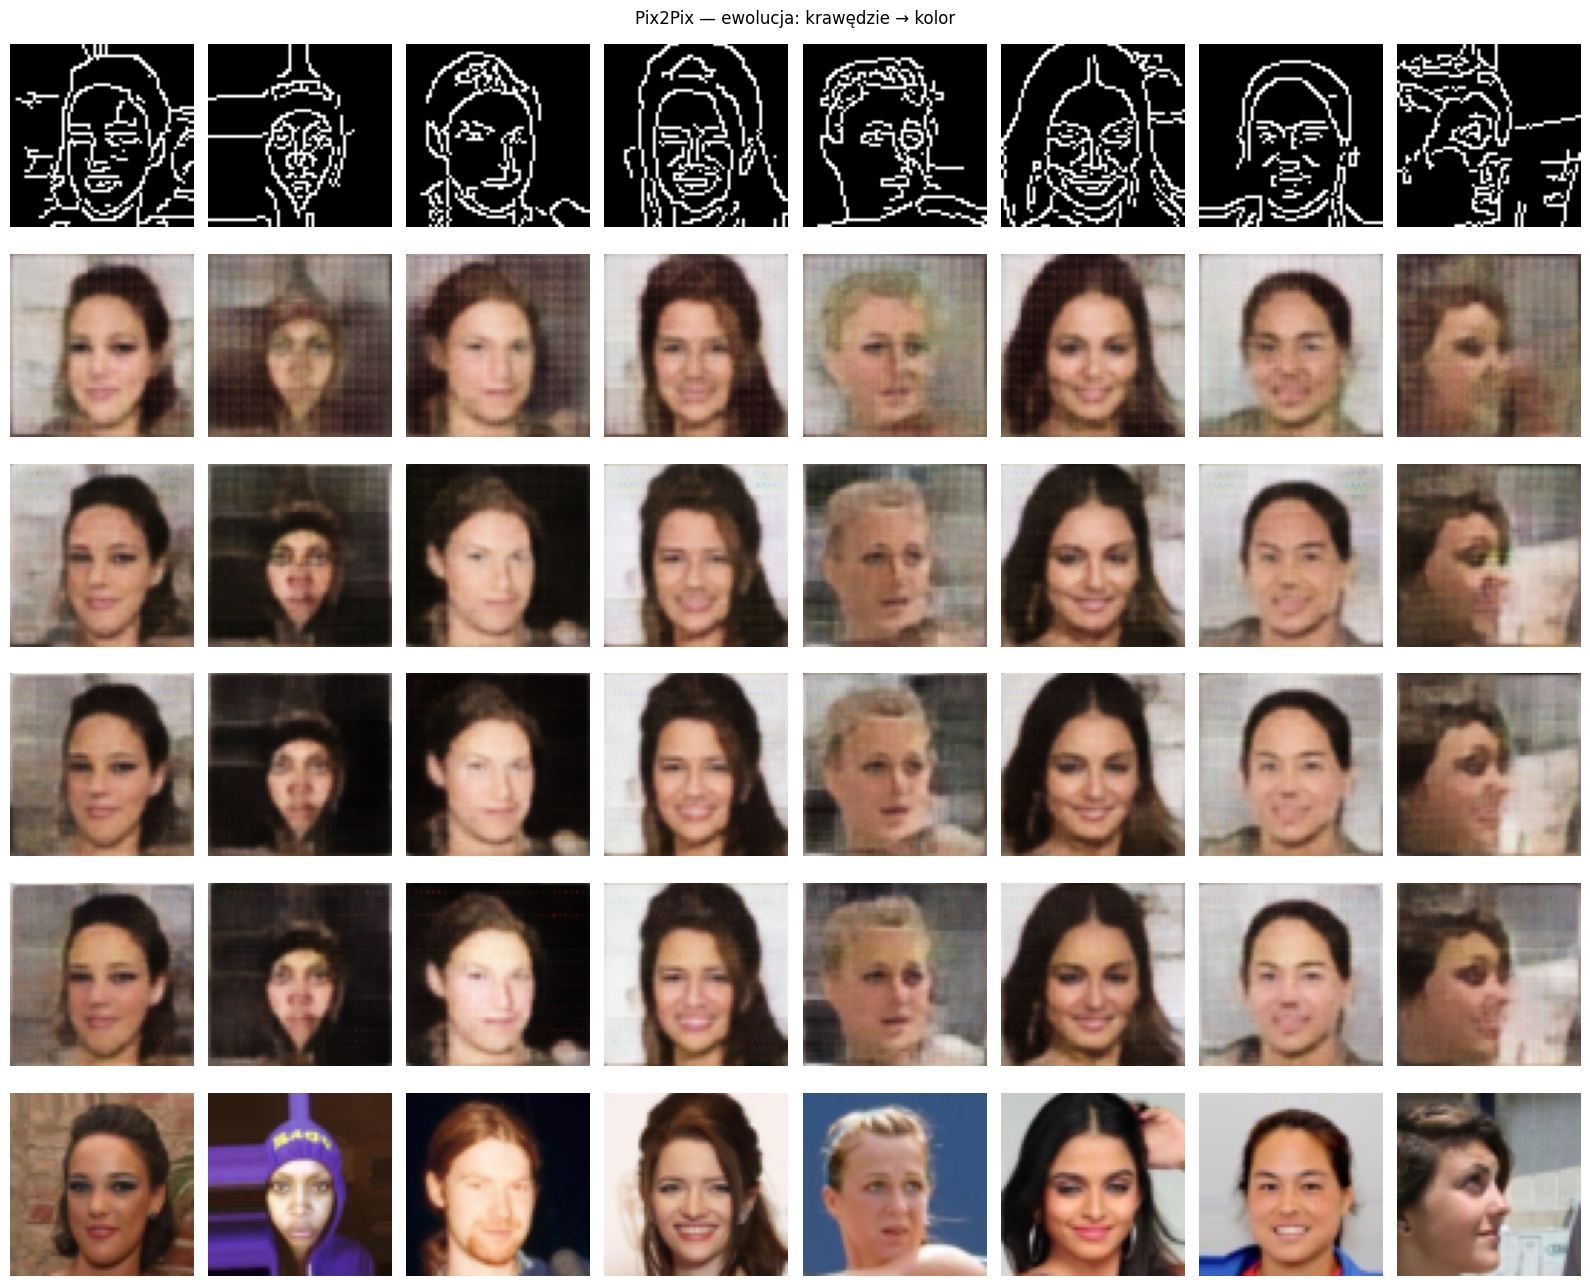

In [21]:
epochs_to_show = [0, MAX_EPOCHS // 4, MAX_EPOCHS // 2, MAX_EPOCHS - 1]

rows = ["Wejście (krawędzie)"] + [f"Epoka {e+1}" for e in epochs_to_show] + ["Cel (kolor)"]
fig, axes = plt.subplots(len(rows), 8, figsize=(16, len(rows) * 2.2))

edges_np = (fixed_edges.cpu().permute(0,2,3,1).numpy()[:,:,:,0] * 0.5 + 0.5).clip(0,1)
color_np = (fixed_color.cpu().permute(0,2,3,1).numpy() * 0.5 + 0.5).clip(0,1)

for col in range(8):
    axes[0][col].imshow(edges_np[col], cmap="gray")
    axes[0][col].axis("off")
    for row_idx, ep in enumerate(epochs_to_show, start=1):
        snap = (epoch_snapshots[ep][col].permute(1,2,0).numpy() * 0.5 + 0.5).clip(0,1)
        axes[row_idx][col].imshow(snap)
        axes[row_idx][col].axis("off")
    axes[-1][col].imshow(color_np[col])
    axes[-1][col].axis("off")

for row_idx, label in enumerate(rows):
    axes[row_idx][0].set_ylabel(label, fontsize=8)

plt.suptitle("Pix2Pix — ewolucja: krawędzie → kolor", fontsize=12)
plt.tight_layout(); plt.show()

## Wyniki końcowe — krawędzie | predykcja | cel

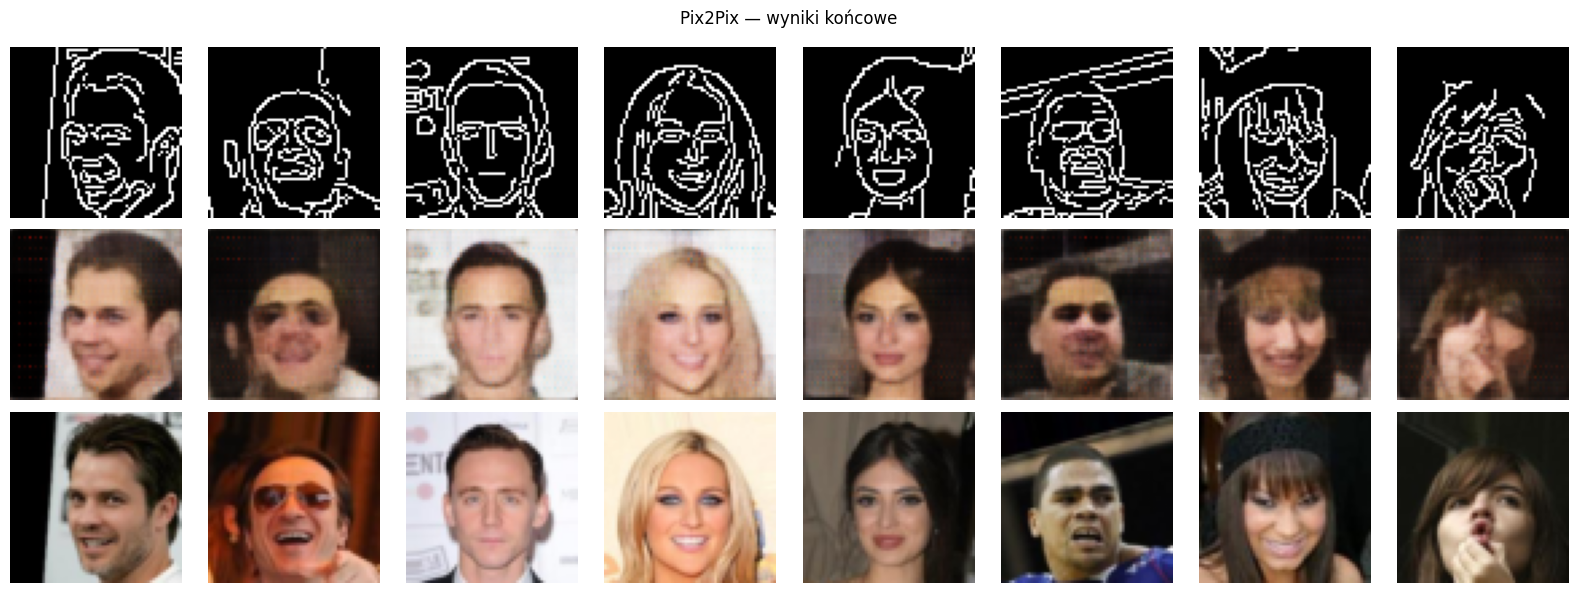

In [22]:
G.eval()
test_edges, test_color = next(iter(data_loader))
test_edges = test_edges[:8].to(DEVICE)

with torch.no_grad():
    pred = G(test_edges).cpu()

edges_np = (test_edges.cpu().permute(0,2,3,1).numpy()[:,:,:,0] * 0.5 + 0.5).clip(0,1)
pred_np  = (pred.permute(0,2,3,1).numpy() * 0.5 + 0.5).clip(0,1)
color_np = (test_color[:8].permute(0,2,3,1).numpy() * 0.5 + 0.5).clip(0,1)

fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for col in range(8):
    axes[0][col].imshow(edges_np[col], cmap="gray")
    axes[1][col].imshow(pred_np[col])
    axes[2][col].imshow(color_np[col])
    for row in range(3):
        axes[row][col].axis("off")

for row, label in enumerate(["Wejście (X)\nkrawędzie", "Predykcja G(X)", "Cel (Y)\nkolor"]):
    axes[row][0].set_ylabel(label, fontsize=9)

plt.suptitle("Pix2Pix — wyniki końcowe", fontsize=12)
plt.tight_layout(); plt.show()